In [1]:
import jax

import zodiax as zdx
import equinox as eqx
import jax.numpy as np
import jax.random as jr
import jax.tree as jtu
import dLux as dl
import dLux.utils as dlu
import optax
import optimistix as optx
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Note we enable 64-bit precision for numerical stability when computing the Hessians
# later in the tutorial!
jax.config.update("jax_enable_x64", True)

/Users/louis/mambaforge/envs/zdx-tuts/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import CenteredNorm

# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 90

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

In [3]:
# Lets check our versions quickly to make sure we can reproduce the results
print(f"zodiax version: {zdx.__version__}")
print(f"equinox version: {eqx.__version__}")
print(f"optax version: {optax.__version__}")
print(f"optimistix version: {optx.__version__}")
print(f"jax version: {jax.__version__}")
print(f"dLux version: {dl.__version__}")

zodiax version: 0.5.0
equinox version: 0.13.4
optax version: 0.2.7
optimistix version: 0.1.0
jax version: 0.8.3
dLux version: 0.14.0


---

# An Overview of Optimising Models within Zodiax

**Exploring how to optimise and analyse scientific models with lots of tips and tricks along the way!**


We will cover a large number of topics in this notebook, slowly stepping up the complexity along the way. Here is a breakdown of the topics:

1. First order gradient descent and optimistaion with [Optax](https://optax.readthedocs.io/en/latest/)
2. Second order optimisation with [Optimistix](https://docs.kidger.site/optimistix/)
3. Estimating uncertainties with Hessians
4. Building (and optimising) hierarchical models
5. Natural gradient descent using the Fisher information matrix
6. Reparametrisation with the Fisher information matrix
7. Posterior sampling with [Numpyro](https://num.pyro.ai/en/stable/)

This should provide a comprehensive overview of all the tools and techniques needed to do inference with scientific models with Zodiax!

Note that while this notebook is designed to be relative self-contained, we will use the [dLux package](https://louisdesdoigts.github.io/dLux/) to build a hierarchical optical model (zodiax was originally built within dLux after all!).

---

## 1. Gradient descent with Optax

This is the most basic starting point, gradient descent on a simple model. We will start with a simple model of a sum of Gaussians as this is very easy to understand and should provide a good springboard to show to use the main optimisation tools with the jax eco-system.

[Optax](https://optax.readthedocs.io/en/latest/) is a first-order gradient processing library for jax. It provides a large number of optimisers, from simple gradient descent to more complex algorithms like Adam and RMSProp. It also provides tools for learning rate schedules, gradient clipping, and more.

In [4]:
# We start by defining a simple zodiax model.
class GaussianModel(zdx.Base):
    """
    A sum of Gaussians defined over a fixed 1D grid, defined by the mean and std of 
    each Gaussian.
    """
    mean: np.ndarray
    std: np.ndarray
    power: np.ndarray
    xs: np.ndarray

    def __init__(self, mean, std, power, width=10, nsamples=500):
        super().__init__()
        self.mean = np.array(mean, float)
        self.std = np.array(std, float)
        self.power = np.array(power, float)

        if self.mean.shape != self.std.shape:
            raise ValueError("Mean and std must have the same shape")

        self.xs = np.linspace(-width, width, nsamples)

    @staticmethod
    def gaussian(x, mean, std, power):
        factor = 1 / (std * np.sqrt(2 * np.pi))
        gauss = np.exp(-0.5 * ((x - mean) / std) ** 2)
        return factor * gauss ** power

    @jax.jit
    def __call__(self, params=None):

        if params is not None:
            self = self.set(params)

        mean = np.atleast_1d(self.mean)
        std = np.atleast_1d(self.std)
        power = np.atleast_1d(self.power)
        eval_fn = lambda mean, std, power: self.gaussian(self.xs, mean, std, power)
        return jax.vmap(eval_fn)(mean, std, power).sum(axis=0)

# Construct the model
model = GaussianModel(mean=[2, -3], std=[0.5, 2], power=[1.5, 1])
print(model)

GaussianModel(mean=f64[2], std=f64[2], power=f64[2], xs=f64[500])


**Generating data and initial parameters**

Now we can generate some data from our model and add some noise. This is the data that we will recover our original parameters from using optax.

We also want to generate an initial guess for our parameters to start the optimisation from. In practice, we would probably estimate our initial values from the data, but here we will just perturb our true values by a small amount for simplicity. It also helps us learn the `jax.random` syntax, which is a bit different to the standard `numpy.random` syntax, but very powerful due to being fully deterministic, allowing for easy reproducibility.

Initial reduced chi-squared: 7.525943757570605


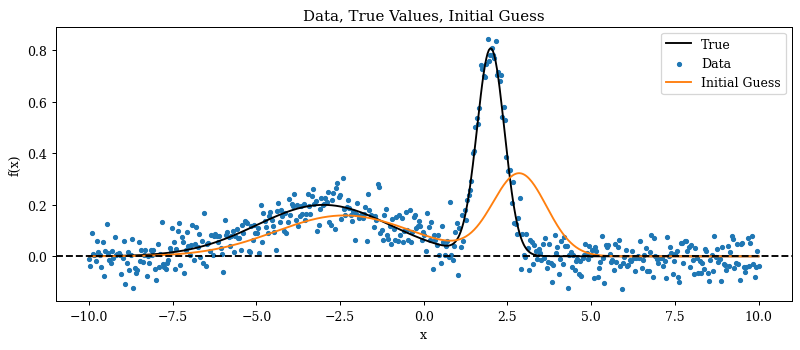

In [5]:
from zodiax import stats

# Generate the true values
true_values = model()

# Add some gaussian noise to the data
error = 0.05
data = true_values + error * jr.normal(jr.key(0), true_values.shape)

# Define our initial guess of parameters
keys = jr.split(jr.key(1), 3)
params = {
    "mean": jr.uniform(keys[0], model.mean.shape) + model.mean,
    "std": jr.uniform(keys[1], model.std.shape) + model.std,
    "power": jr.uniform(keys[2], model.power.shape) + model.power,
}
initial = model(params)

# Look at the initial reduced chi-squared statistic
chi2r = stats.chi2r(initial, data, error, stats.ddof(params, data))
print("Initial reduced chi-squared:", chi2r)

# Look at the data and the true values
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(model.xs, true_values, label="True", c="k")
ax.scatter(model.xs, data, s=10, alpha=1.0, label="Data")
ax.plot(model.xs, initial, c="C1", label="Initial Guess")
ax.axhline(0, color="k", linestyle="--")
ax.set(xlabel="x", ylabel="f(x)", title="Data, True Values, Initial Guess")
ax.legend()
plt.tight_layout()
plt.show()

**Optimisation**

Okay great, now lets have a look at how we can use optax to recover the original parameters of our model. To do this, we need to define a loss function and define an optax optimiser. Since scientific models are often parametrised by physical parameters, zodiax provides a simple interface to map different optimisers to different parameters.

For our loss function we will use the mean square of the z-score (i.e. the chi-squared statistic). This has the nice property of having gradients proportional to the normal log-likelihood, but is invariant to the size of the data and provides losses closer to unity, which can be easier to work with when tuning learning rates and other hyperparameters.

To define the optimisation algorithm we can use a dictionary to map a series of optimisers to our different leaves. In this case, we will use a simple stochastic gradient descent (SGD) algorithm with a small learning rate and some momentum. We will also delay the optimisation for the power parameter by 50 steps to allow the mean and std to converge first. In practice, you can use any optax optimisers, schedulers and learning rates for each parameter. Note the syntax that we use to map _multiple_ parameters to the same optimiser, which can be very useful when you have a large number of parameters that you want to treat the same way.

We can then use the zodiax `map_optimisers` function to map our optimisers to our parameters and get the initial state for our optimisation. From there we can very simply run a loop to perform the optimisation, applying the updates to our parameters at each step while tracking our loss value.

In [6]:
from zodiax import optimisation as opt

# Simple loss function that we will use for optimisation
def loss_fn(params, args):
    model, data, error = args
    z = stats.z_score(model(params), data, error)
    return np.square(z).mean()

# JIT and grad transform the loss function
loss_grad_fn = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn))

# Define our optimisers that we map to each parameter
optimisers = {
    ("mean", "std"): optax.sgd(0.002, momentum=0.5),
    "power": optax.sgd(opt.delay(0.005, 50), momentum=0.5),
}

# Now we map the optimisers to the parameters and get the initial state
optim, state = opt.map_optimisers(params, optimisers)

# Bundle up the arguments
args = (model, data, error)

# Now we can run a simple optimisation loop
losses = []
for step in tqdm(range(500)):
    loss, grads = loss_grad_fn(params, args)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    losses.append(loss)
losses = np.array(losses)

100%|██████████| 500/500 [00:00<00:00, 671.04it/s]


Now we can take a look at our loss curve and check the final value of our reduced chi-squared statistic to see how well we did. We can also look at the final parameters to see how close we got to the true values.

Final reduced chi-squared: 1.0707949059930015


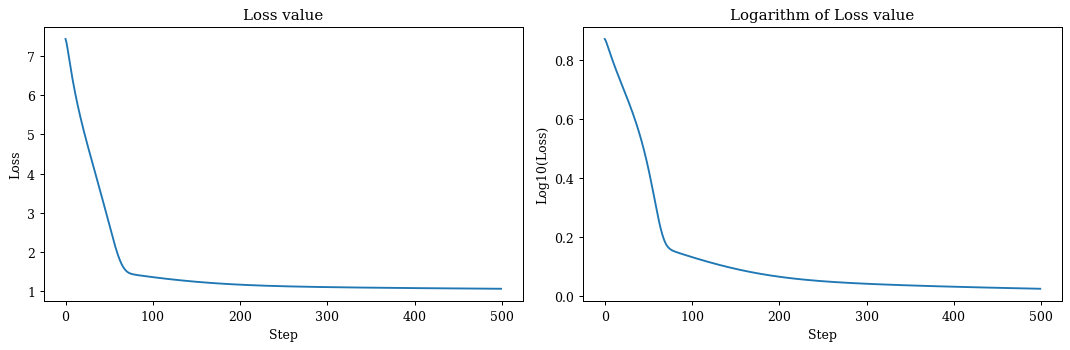

In [7]:
# Check the final reduced chi-squared statistic
chi2r = stats.chi2r(model(params), data, error, stats.ddof(params, data))
print("Final reduced chi-squared:", chi2r)

plt.figure(figsize=(12, 4))
ax = plt.subplot(1, 2, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(1, 2, 2)
ax.plot(np.log10(losses))
ax.set(title="Logarithm of Loss value", xlabel="Step", ylabel="Log10(Loss)")

plt.tight_layout()
plt.show()

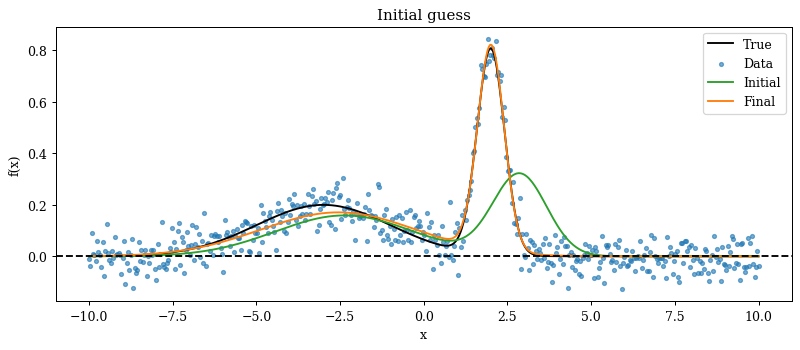

In [8]:
# Get the final model values
final = model(params)

# Look at the data, true values, initial and final model
plt.figure(figsize=(9, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(model.xs, true_values, label="True", c="k")
ax.scatter(model.xs, data, s=10, alpha=0.6, label="Data", c="C0")
ax.plot(model.xs, initial, label="Initial", c="C2")
ax.plot(model.xs, final, label="Final", c="C1")
ax.axhline(0, color="k", linestyle="--")
ax.set(xlabel="x", ylabel="f(x)", title="Initial guess")
ax.legend()
plt.tight_layout()
plt.show()

Okay great, that is the basics of how to use optax to optimise our model parameters. The good thing about this approach is that it is very flexible and we can build our own more advanced algorithms, optimisation techniques, and normalisation and integrate them directly. We will look at these a bit later, but for now lets look at how to use the more powerful second-order optimisation techniques with Optimistix.

---

## 2. Optimisation with Optimistix

Now we can start to look at some second order optimisation algorithms within [Optimistix](https://docs.kidger.site/optimistix/). This is a simple translation, mostly requiring us to slightly change our loss function input signature. We will keep working with our simple sum of Gaussians model for now, so lets just jump straight into it!

Optimistix requires a loss function with the signature `loss_fn(params, args)`, where `args` is a tuple of any additional arguments that we want to pass to our loss function. It's very simple to translate our previous loss function to this new signature. Also note that we don't want to apply any jit or grad transformations to our loss function, as Optimistix will do this for us automatically when we call the `minimise` function.

In [9]:
# Re-initialise our guess of parameters
keys = jr.split(jr.key(1), 3)
params = {
    "mean": jr.uniform(keys[0], model.mean.shape) + model.mean,
    "std": jr.uniform(keys[1], model.std.shape) + model.std,
    "power": jr.uniform(keys[2], model.power.shape) + model.power,
}

# Apply the optimiser
args = (model, data, error)
solver = optx.BestSoFarMinimiser(optx.BFGS(rtol=1e-12, atol=1e-12))
sol = optx.minimise(loss_fn, solver, params, args)

Now we can take a quick look at our results after optimisation. We can see that we have successfully recovered our original parameters, and our reduced chi-squared statistic is very close to unity, indicating a good fit to the data.

Final reduced chi-squared: 1.0282461240223641
Steps: 27


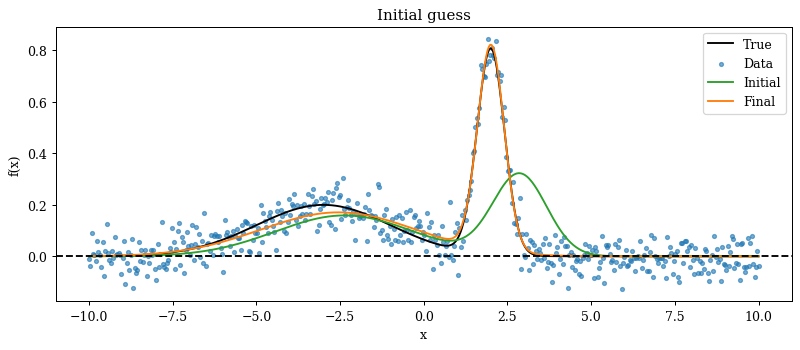

In [10]:
# Check the final reduced chi-squared statistic
chi2r = stats.chi2r(model(sol.value), data, error, stats.ddof(params, data))
print("Final reduced chi-squared:", chi2r)
print("Steps:", int(sol.stats["num_steps"]))

# Check the outputs of the optimiser
plt.figure(figsize=(9, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(model.xs, true_values, label="True", c="k")
ax.scatter(model.xs, data, s=10, alpha=0.6, label="Data", c="C0")
ax.plot(model.xs, initial, label="Initial", c="C2")
ax.plot(model.xs, final, label="Final", c="C1")
ax.axhline(0, color="k", linestyle="--")
ax.set(xlabel="x", ylabel="f(x)", title="Initial guess")
ax.legend()
plt.tight_layout()
plt.show()

---

## 3. Estimating Uncertainties

Now that we have optimised our parameters, we can take a look at how to estimate the uncertainties on our parameters. Luckily, with autodiff, we can do this quite easily using the second derivatives of the likelihood function - ie via the Hessian matrix. The inverse of the Hessian at the optimum gives us the covariance matrix of our recovered parameters, which provides an estimate of the uncertainties on our parameters! It's important to note that this is only an estimate, and relies on the assumption that the likelihood surface is well approximated by a Gaussian near the optimum, which may not always be the case. More complex posteriors require sampling methods like MCMC or variational inference, which we will cover later in the tutorial.

It's important to note that we need to use the _true_ likelihood function. So far, we have been taking the _mean_ of our log likelihood across our data points, which is fine for optimisation, but we require the sum of the log likelihoods to get the correct Hessian and covariance estimates. This is a common mistake that can lead to incorrect uncertainty estimates!

Given that the hessian matrix is a second-order derivative calculation, it is common to run into memory issues when calculating them. Zodiax provides some wrappers around the default jax jacobian and hessian functions, designed to lower ram usage by batching the calculations across multiple steps, so lets have a look at how to use these to estimate our parameter uncertainties.

Another common gotcha is that hessian calculations on physical models can often suffer from precision limitations when using 32-bit calculations. This usually leads to nan values in the hessian, so if you run into issues, make sure your first check is to run your code with 64-bit precision enabled. In jax, this needs to be done at the _start_ of a script or notebook. You can look at how to do this at the top of this notebook.

In [11]:
from zodiax import batching

# Define the likelihood function to compute the Hessian of
def likelihood(params, args):
    model, data, error = args
    return -stats.loglike(model(params), data, error).sum()


# The hessian function requires the input signature f(x), so here we will format our
# function to have this signature. Note that we can keep our parameters in dictionary or
# pytree form!
f = lambda params: likelihood(params, args)

# Evaluate the Hessian at the solution found by optimistix. Increase the number of
# batches to reduce the memory usage!
H, unflatten = batching.hessian(f, sol.value, nbatches=2)

# The covariance matrix estimate is given by the inverse of the Hessian!
covariance = np.linalg.inv(H)

# We can now get our uncertainty estimates on the parameters by taking the square root
# of the diagonal of the covariance matrix, and unflattening it to the same structure
# as our parameters.
std = unflatten(np.diag(covariance) ** 0.5)

Great now lets have a look at our hessian and covariance matrix!

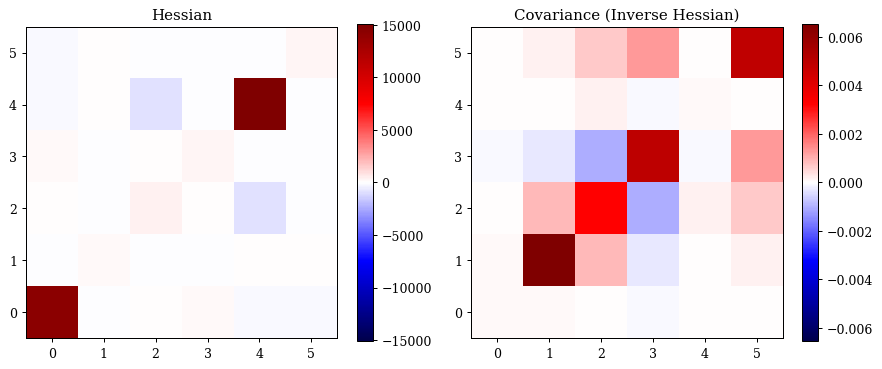

In [12]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Hessian")
plt.imshow(H, seismic, norm=CenteredNorm())
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Covariance (Inverse Hessian)")
plt.imshow(covariance, seismic, norm=CenteredNorm())
plt.colorbar()

plt.tight_layout()
plt.show()

Now lets look at our parameter uncertainties directly

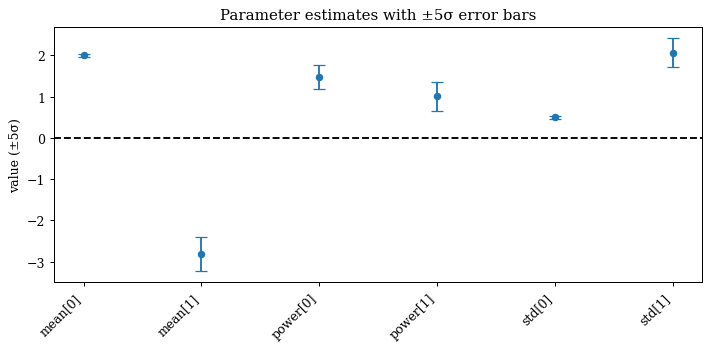

In [13]:
labels, y, yerr = [], [], []
for k in sol.value:
    v = np.atleast_1d(np.asarray(sol.value[k]))
    e = np.atleast_1d(5 * np.asarray(std[k]))

    for i in range(v.size):
        labels += [f"{k}[{i}]"]
        y += [float(v.reshape(-1)[i])]
        yerr += [float(e.reshape(-1)[i])]

x = np.arange(len(labels))

plt.figure(figsize=(8, 4))
plt.title("Parameter estimates with ±5σ error bars")
plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=5, ms=5)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("value (±5σ)")
plt.axhline(0, color="k", linestyle="--")
plt.tight_layout()
plt.show()

---

## 4. Building Hierarchical Models

Great, now we have an overview of how to do basic optimisation and uncertainty estimation, lets start looking at more complex hierarchical models, and use them as a springboard to more advanced methods like natural gradient descent, reparametrisation, and posterior sampling. 

We will use the [dLux package](https://louisdesdoigts.github.io/dLux/) to build a hierarchical optical model, given that zodiax was originally developed as an internal module for dLux! If you're not familiar with dLux, optics, or astronomy, don't worry, the model and problems themselves are not important and we will go through exactly what we are doing in simple terms. To avoid the specific of the optical model, we will import one to skip straight to the optimisation.

**The Hierarchical Optical Problem**

The problem we are tackling here is hierarchically solving for both the state of the optical system - its 'aberrations', ie bending of the mirror - while also solving for the position and brightness of stars imaged with multiple different filters. The aberrations are constrained by the images taken in each filter, whereas the position and brightness of the stars are only constrained by the images taken in their respective filters. This is the general structure of our hierarchical problem.

In [14]:
from scripts.optics import build_optics

# Lets build our optical system by defining our three filters - Note these are not
# actually 'red', 'green' and 'blue' filters, just some arbitrary filters!
optics = build_optics(
    filters={
        "blue": np.linspace(1, 1.2, 5),
        "green": np.linspace(1.2, 1.4, 5),
        "red": np.linspace(1.4, 1.6, 5),
    }
)

# Lets have a quick look at the optics model
optics

AngularOpticalSystem(
  wf_npixels=256,
  diameter=1.2,
  layers={
    'aperture': TransmissiveLayer(transmission=f64[256,256], normalise=True),
    'wfe': BasisLayer(basis=f64[7,256,256], coefficients=f64[7], as_phase=False)
  },
  psf_npixels=32,
  oversample=1,
  psf_pixel_scale=0.075,
  filters={'blue': f64[5], 'green': f64[5], 'red': f64[5]}
)

**A simple hierarchical model**

So how do we make our model hierarchical? This is quite simple, and here I will show a design structure to do this (and is used by the [Amigo pipeline](https://github.com/LouisDesdoigts/amigo) used to model JWST data using dLux and zodiax!). For this we only need to define an `Observation` class that that holds our data, and a method that defines how to use our optical system to model the data, thats about it! It's worth noting that there is nothing special about this structure, you can build your model in whatever way you would prefer, this is just one way to do it that I find works well for this type of problem.



In [15]:
# A simple observation class that defines how to model the data with the optical model
# Note we can use the __call__ method to re-parametrise our parameters to keep things
# in favorable units
class Observation(zdx.Base):
    data: np.ndarray
    error: np.ndarray
    filter: str

    def __init__(self, data, error, filter):
        self.data = np.array(data, float)
        self.error = np.array(error, float)
        self.filter = str(filter)

    def __call__(self, params, optics):
        """
        Takes in the parameters and optical model, returning a prediction of the data.
        Also re-parametrises the unit of position into arcseconds, the flux into 
        log(flux) and the wavefront error into nanometers to keep things in favorable 
        units for optimisation or convention.
        """
        # Unpack the wavelengths
        wavels = 1e-6 * optics.filters[self.filter]

        # Unpack the position and convert from arcseconds
        position = dlu.arcsec2rad(params["position"][self.filter])

        # Unpack the flux and convert from log
        flux = 10 ** params["flux"][self.filter]

        # Update the optics model with the WFE coefficients
        optics = optics.set("wfe.coefficients", 1e-9 * params["wfe"])

        # Compute the PSF using the optics model and the wavefront error
        return flux * optics.propagate(wavels, position)

    def est_pos(self, optics):
        """
        Estimate the position of the source in the image by finding the pixel with the 
        maximum value, and converting it to the correct units. Note this is just a 
        used as a simple estimate for initialisation purposes, no more.
        """
        iy, ix = np.unravel_index(np.argmax(self.data), self.data.shape)
        ix = ix - self.data.shape[1] / 2
        iy = iy - self.data.shape[0] / 2
        return np.array([ix, iy]) * optics.psf_pixel_scale


# Simple function to simulate an image given a PSF, including Poisson and read noise
def take_image(psf, seed, read_noise=10):
    """Takes in a PSF and adds realistic noise to simulate a realistic image."""
    keys = jr.split(jr.key(seed), 2)
    photons = jr.poisson(keys[0], psf)
    read = read_noise * jr.normal(keys[1], psf.shape)
    return photons + read

# Now we can construct our dummy observations, one for each filter. Note we will
# populate the data and error arrays with real values later, we just use this to model
# the psf's used to simulate some data
observations = [Observation(0.0, 0.0, filter) for filter in optics.filters]

# Lets have a quick look at the observation objects
observations

[Observation(data=f64[], error=f64[], filter='blue'),
 Observation(data=f64[], error=f64[], filter='green'),
 Observation(data=f64[], error=f64[], filter='red')]

Now lets define our true parameters that we will use for simulation, and try and recover

In [16]:
# Set the true parameters for the simulation
keys = jr.split(jr.key(0), 3)
n_filters = len(optics.filters)

# Stellar positions, units of arcseconds
true_positions = 0.1 * jr.normal(keys[0], (n_filters, 2))

# Stellar brightness, with units of log10 photons
true_fluxes = 6 * jr.uniform(keys[1], (n_filters,), minval=0.8, maxval=1.2)

# Wavefront error coefficients, with units of nanometers
true_wfe = 50 * jr.normal(keys[2], optics.coefficients.shape)

# Define our hierarchical model parameters
true_params = {
    "wfe": true_wfe,
    "position": {obs.filter: true_positions[i] for i, obs in enumerate(observations)},
    "flux": {obs.filter: true_fluxes[i] for i, obs in enumerate(observations)},
}

Now that we have our true parameter values, we can simulate some data and populate our observation objects

In [17]:
# Generate the true PSFs for each observation
psfs = np.array([obs(true_params, optics) for obs in observations])

# Simulate a number of images to get an estimate of the mean and error on each pixel
n_ims = 1000
raw_data = jax.vmap(lambda seed: take_image(psfs, seed))(np.arange(n_ims))
data = raw_data.mean(0)
error = raw_data.std(0) / np.sqrt(raw_data.shape[0])

# Populate our observations with the data and error
observations = [
    obs.set(["data", "error"], [d, e]) for obs, d, e in zip(observations, data, error)
]

Now we can look at our simulated data, an image of a single star in each filter. Note that the blue filter shows nan values, but thats just because the read-noise results in the average value across the 1000 simulated images being negative, which results in nans when we take the square root to get the error, which is to be expected!

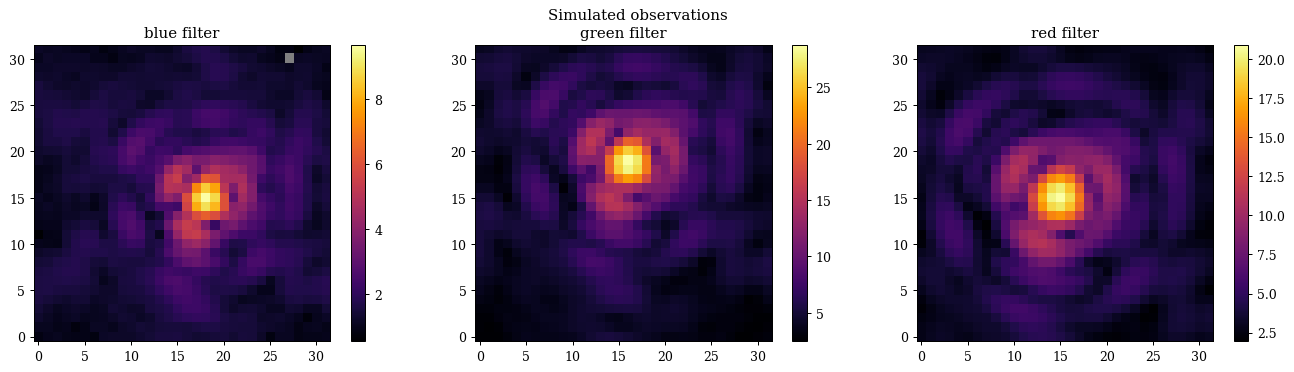

In [18]:
plt.figure(figsize=(15, 4))
plt.suptitle("Simulated observations")

for i, obs in enumerate(observations):
    plt.subplot(1, 3, i + 1)
    plt.title(f"{obs.filter} filter")
    plt.imshow(obs.data**0.25, inferno)
    plt.colorbar()

plt.tight_layout()
plt.show()

**Optimisation**

Now we can optimise our model! We will start here with our simple gradient descent method, as this will serve as a benchmark to compare our more advanced methods to later on. As usual we will define our loss function, optimisers, and then run the optimisation loop

In [19]:
# Simple helper function to evaluate the z-score for a single observation
def eval_z_score(params, model, obs):
    return stats.z_score(obs(params, model), obs.data, obs.error)

# Small wrapper to compute the reduced chi-squared statistic
def get_reduced_chi2(params, optics, observations):
    zs = np.array([eval_z_score(params, optics, obs) for obs in observations])
    data = np.array([obs.data for obs in observations])
    return stats.chi2r_from_z(zs, stats.ddof(params, data))

# Simple z-score loss function as before
def loss_fn(params, args):
    """
    Loss function that takes the _mean_ of the squared z-scores across all pixels
    for each observation, and sums across all observations.
    """
    model, observations = args
    zs = np.array([eval_z_score(params, model, obs) for obs in observations])
    return np.mean(np.square(zs).sum(0))

# JIT and grad transform the loss function
loss_grad_fn = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn))

# Estimate our initial parameters from the data
params = {
    "wfe": np.zeros(7),
    "position": {obs.filter: obs.est_pos(optics) for obs in observations},
    "flux": {obs.filter: np.log10(obs.data.sum()) for obs in observations},
}

# Look at the initial reduced chi-squared statistic
print("initial reduced chi-squared:", get_reduced_chi2(params, optics, observations))

# Define our optimisers that we map to each parameter
optimisers = {
    "position": optax.sgd(1e-10, momentum=0.5),
    "wfe": optax.sgd(opt.delay(1e-4, 25), momentum=0.5),
    "flux": optax.sgd(opt.delay(1e-9, 50), momentum=0.5),
}

# Now we map the optimisers to the parameters and get the initial state
optim, state = opt.map_optimisers(params, optimisers)

# Bundle up the arguments
args = (optics, observations)

# Now we can run a simple optimisation loop
epochs = 200
pbar = tqdm(range(epochs))
losses, params_history = [], []
for step in pbar:
    loss, grads = loss_grad_fn(params, args)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix(log_loss=f"{np.log10(loss):.4f}")
    losses.append(loss)
    params_history.append(params)
losses = np.array(losses)

# Look at the final reduced chi-squared statistic
print("Final reduced chi-squared:", get_reduced_chi2(params, optics, observations))

initial reduced chi-squared: 1553037.1824619938


100%|██████████| 200/200 [00:04<00:00, 48.82it/s, log_loss=3.6472]


Final reduced chi-squared: 1478.1168068610625


Hmm, it looks like our our final reduced chi-squared is still quite high. Lets have a look at our results and parameters to see whats going on (and why we may want to use more advanced optimisation techniques to solve this problem!)

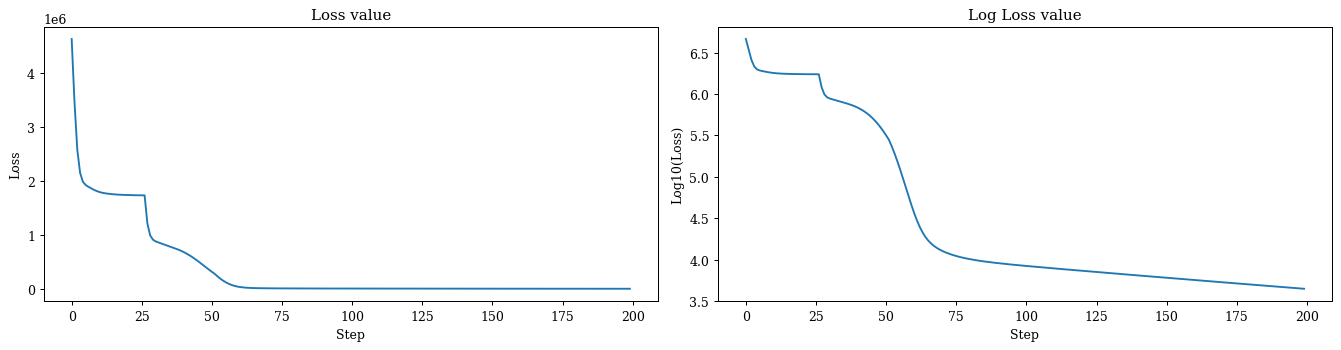

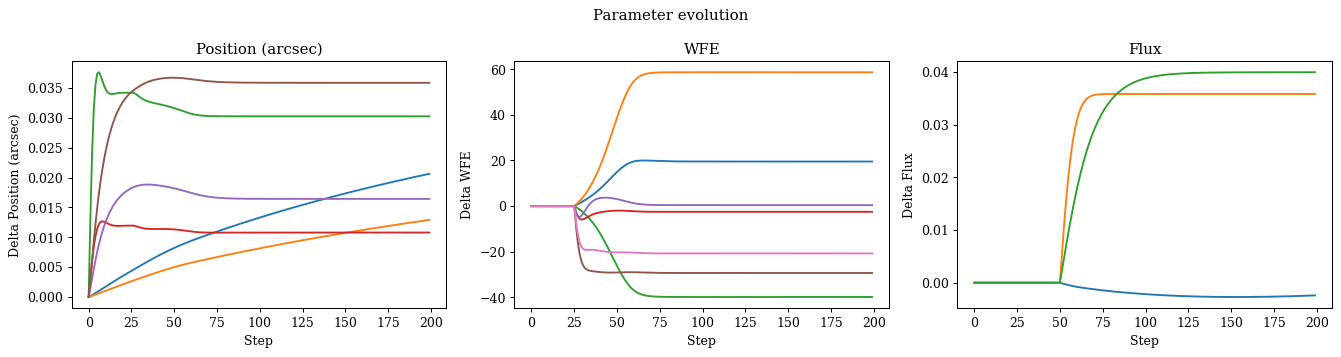

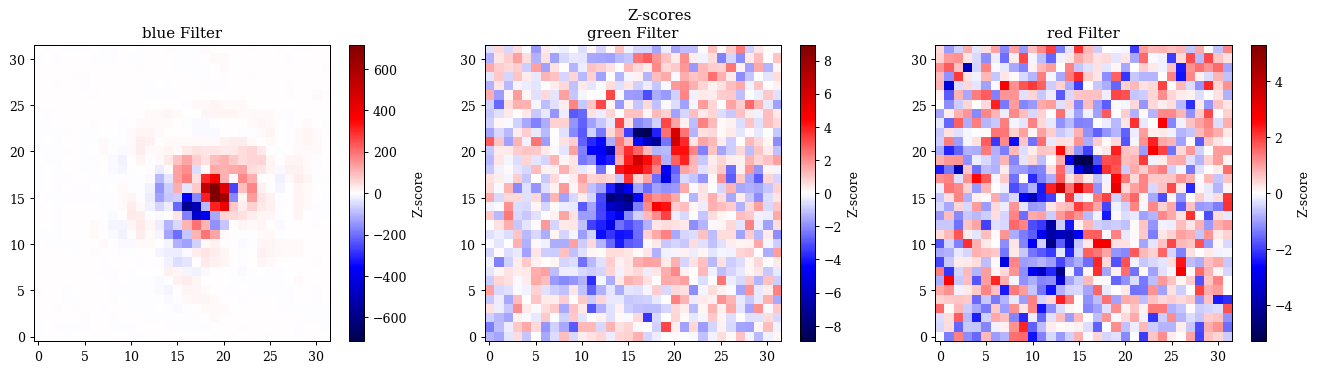

In [20]:
# Map the parameter history to arrays for plotting
positions = np.array([jtu.leaves(params["position"]) for params in params_history])
fluxes = np.array([jtu.leaves(params["flux"]) for params in params_history])
wfe = np.array([jtu.leaves(params["wfe"]) for params in params_history])

# Shift the parameters to show the delta from the initial value
delta_pos = (positions - positions[0]).reshape(epochs, -1)
delta_flux = (fluxes - fluxes[0]).reshape(epochs, -1)
delta_wfe = (wfe - wfe[0]).reshape(epochs, -1)


# Plot the losses
plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 2, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(1, 2, 2)
ax.plot(np.log10(losses))
ax.set(title="Log Loss value", xlabel="Step", ylabel="Log10(Loss)")

plt.tight_layout()
plt.show()


# Plot the parameter evolution
plt.figure(figsize=(15, 4))
plt.suptitle("Parameter evolution")
ax = plt.subplot(1, 3, 1)
ax.set(title="Position (arcsec)", xlabel="Step", ylabel="Delta Position (arcsec)")
plt.plot(delta_pos)

ax = plt.subplot(1, 3, 2)
ax.set(title="WFE", xlabel="Step", ylabel="Delta WFE")
plt.plot(delta_wfe)

ax = plt.subplot(1, 3, 3)
ax.set(title="Flux", xlabel="Step", ylabel="Delta Flux")
plt.plot(delta_flux)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.suptitle("Z-scores")

for i, obs in enumerate(observations):
    res = (obs.data - obs(params, optics)) / obs.error
    v = np.nanmax(np.abs(res))
    plt.subplot(1, 3, i + 1)
    plt.title(f"{obs.filter} Filter")
    plt.imshow(res, cmap="seismic", vmin=-v, vmax=v)
    plt.colorbar(label="Z-score")

plt.tight_layout()
plt.show()

Okay, this tells us a lot! We can see that while we have basically converged on two of our filters, the blue filter is still quite far from the true values! If we look at our parameter evolution curves we can see that while the red and green filter values converge very quickly, the blue filter values take _much_ longer. Don't worry, this is exactly why we chose _this_ hierarchical problem - It's hard for simple approaches!

I should note that we _could_ uniquely tune the learning rate for each parameter in each filter, that isn't really practical for any problems at scale. We should also note here that our learning rates cover many order of magnitudes, which makes it challening to find a good learning rate for each one individually especially for each new set of observations we might want to solve for. We could also run the optimisation for longer, but that isn't efficient, and there are more clever ways to approach this problem. 

---

## 5. Natural Gradient Descent

Natural gradient descent is an optimisation technique that takes into account the geometry of the parameter space by using the Fisher information matrix to precondition the gradients. This can lead to faster convergence, better performance, and can be applied quite simply to hierarchical problems too! In this section, we will implement natural gradient descent using the Fisher information matrix for our hierarchical optical model.

In [21]:
# Estimate our initial parameters from the data
params = {
    "wfe": np.zeros(7),
    "position": {obs.filter: obs.est_pos(optics) for obs in observations},
    "flux": {obs.filter: np.log10(obs.data.sum()) for obs in observations},
}

# Simulate the data at our initial guess to calculate the Fisher information matrix
n_ims, read_noise = 1000, 10
psfs = np.array([obs(params, optics) for obs in observations])
errors = np.sqrt((psfs + read_noise**2) / n_ims)

# Populate our dummy observations with the simulate data
simulated_observations = [
    obs.set(["data", "error"], [data, error])
    for data, error, obs in zip(psfs, errors, observations)
]

# Bundle up the arguments
args = (optics, simulated_observations)

# Calculate the Fisher information matrix at our initial guess
f = lambda params: loss_fn(params, args)
F, unflatten = batching.hessian(f, params)
C = np.linalg.inv(F)

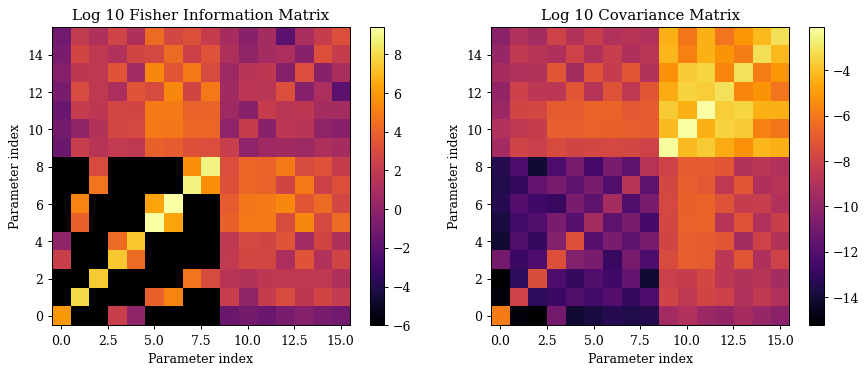

In [22]:
plt.figure(figsize=(10, 4))
ax = plt.subplot(1, 2, 1)
plt.imshow(np.log10(np.abs(F + 1e-6)))
plt.colorbar()
ax.set(
    title="Log 10 Fisher Information Matrix",
    xlabel="Parameter index",
    ylabel="Parameter index",
)

ax = plt.subplot(1, 2, 2)
plt.imshow(np.log10(np.abs(C)))
plt.colorbar()
ax.set(
    title="Log 10 Covariance Matrix",
    xlabel="Parameter index",
    ylabel="Parameter index",
)

plt.tight_layout()
plt.show()

In [23]:
from jax.flatten_util import ravel_pytree

# Look at the initial reduced chi-squared statistic
print("initial reduced chi-squared:", get_reduced_chi2(params, optics, observations))

# Define our optimisers that we map to each parameter
optimisers = {
    "position": optax.sgd(1e-1, momentum=0.5),
    "wfe": optax.sgd(opt.delay(1e-1, 25), momentum=0.5),
    "flux": optax.sgd(opt.delay(1e-1, 50), momentum=0.5),
}

# Now we map the optimisers to the parameters and get the initial state
optim, state = opt.map_optimisers(params, optimisers)

# Bundle up the arguments
args = (optics, observations)

# Now we can run a simple optimisation loop
epochs = 100
pbar = tqdm(range(epochs))
losses, params_history = [], []
for step in pbar:
    loss, grads = loss_grad_fn(params, args)

    # Normalise the gradients by the fisher matrix to get a natural gradient step
    G, unflatten = ravel_pytree(grads)
    grads = unflatten(np.dot(G, C))

    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix(log_loss=f"{np.log10(loss):.4f}")
    losses.append(loss)
    params_history.append(params)
losses = np.array(losses)

# Look at the final reduced chi-squared statistic
print("Final reduced chi-squared:", get_reduced_chi2(params, optics, observations))

initial reduced chi-squared: 1553037.1824619938


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 60.69it/s, log_loss=0.4635]


Final reduced chi-squared: 0.9742225768208455


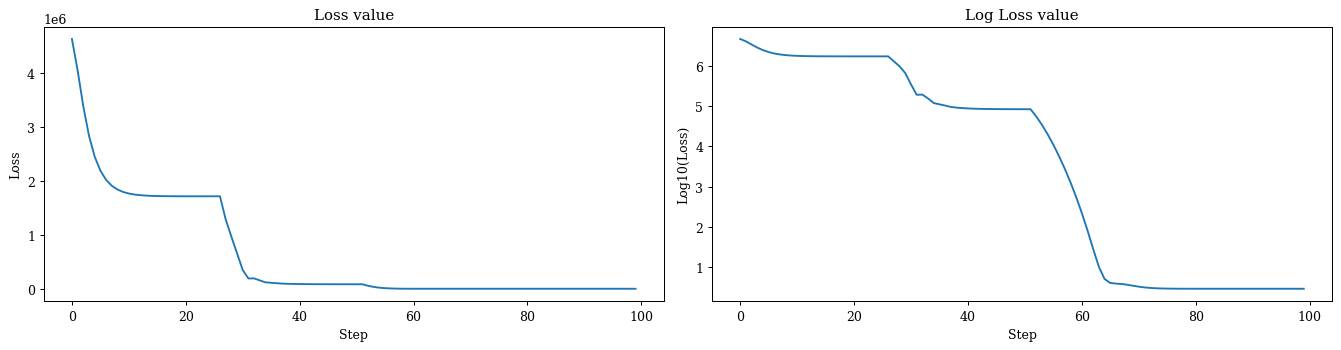

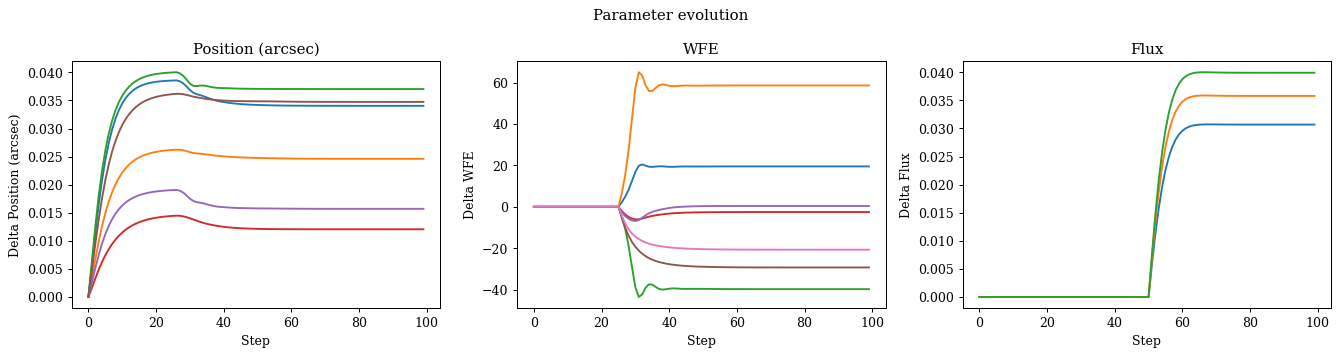

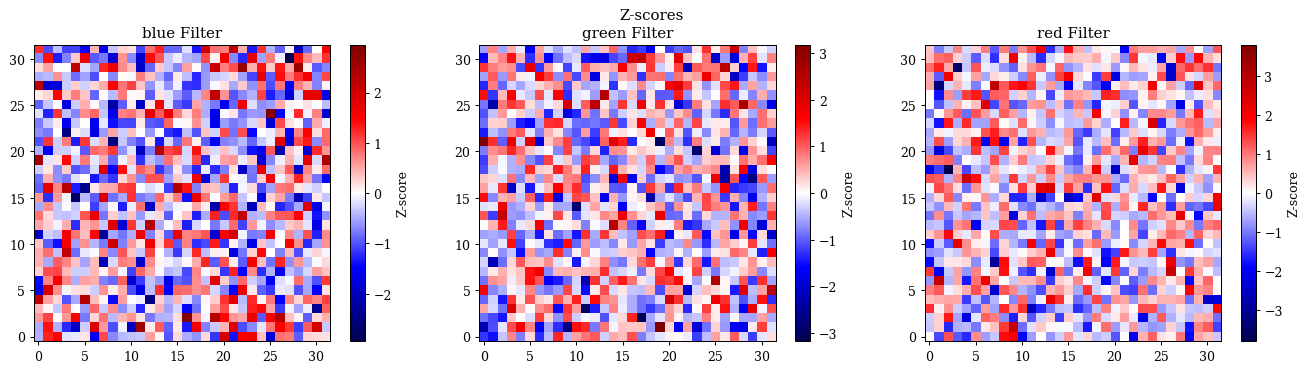

In [24]:
# Map the parameter history to arrays for plotting
positions = np.array([jtu.leaves(params["position"]) for params in params_history])
fluxes = np.array([jtu.leaves(params["flux"]) for params in params_history])
wfe = np.array([jtu.leaves(params["wfe"]) for params in params_history])

# Shift the parameters to show the delta from the initial value
delta_pos = (positions - positions[0]).reshape(epochs, -1)
delta_flux = (fluxes - fluxes[0]).reshape(epochs, -1)
delta_wfe = (wfe - wfe[0]).reshape(epochs, -1)

# Plot the losses
plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 2, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(1, 2, 2)
ax.plot(np.log10(losses))
ax.set(title="Log Loss value", xlabel="Step", ylabel="Log10(Loss)")

plt.tight_layout()
plt.show()

# Plot the parameter evolution
plt.figure(figsize=(15, 4))
plt.suptitle("Parameter evolution")
ax = plt.subplot(1, 3, 1)
ax.set(title="Position (arcsec)", xlabel="Step", ylabel="Delta Position (arcsec)")
plt.plot(delta_pos)

ax = plt.subplot(1, 3, 2)
ax.set(title="WFE", xlabel="Step", ylabel="Delta WFE")
plt.plot(delta_wfe)

ax = plt.subplot(1, 3, 3)
ax.set(title="Flux", xlabel="Step", ylabel="Delta Flux")
plt.plot(delta_flux)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.suptitle("Z-scores")

for i, obs in enumerate(observations):
    res = (obs.data - obs(params, optics)) / obs.error
    v = np.nanmax(np.abs(res))
    plt.subplot(1, 3, i + 1)
    plt.title(f"{obs.filter} Filter")
    plt.imshow(res, cmap="seismic", vmin=-v, vmax=v)
    plt.colorbar(label="Z-score")

plt.tight_layout()
plt.show()

Great, as we can see, the natural gradient descent has significantly improved our convergence. There are a few important things to notice here, first we can see we have recovered all of the information from the data by looking at the z-scores. Secondly, as we can see, now all of the parameters converge at about the same rate, allowing us to use far fewer steps than before. Finally, we can see that all of our learning rates are the same and approximately unity, making it much easier to tune and apply to new problems without needing to worry about the scale of the parameters or the data. This is the power of natural gradient descent, and why it is such a popular technique for optimising complex models, especially hierarchical ones!

---

## 6. Reparametrisation

We can also use the Fisher information matrix to reparametrise our problem, which can also lead to faster convergence and better performance! This is similar to natural gradient descent, but instead of transforming the gradients, we now transform the parameters themselves. This can be useful when we want to use more black-box optimisers in optimistix. Note that we _can_ access and modify the gradient information in optimistix but requires more work. 

To start, lets see how this problem performs natively within optimistix on the true parameter scales. We can follow the optimistix set we up used earlier.

In [25]:
# Estimate our initial parameters from the data
params = {
    "wfe": np.zeros(7),
    "position": {obs.filter: obs.est_pos(optics) for obs in observations},
    "flux": {obs.filter: np.log10(obs.data.sum()) for obs in observations},
}

# Get initial reduced chi-squared
print("Initial reduced chi-squared:", get_reduced_chi2(params, optics, observations))

## Minimise algorithms ###
solver = optx.BestSoFarMinimiser(optx.LBFGS(rtol=1e-6, atol=1e-6))
sol = optx.minimise(loss_fn, solver, params, args, max_steps=512, throw=False)

# Get final reduced chi-squared
print("Final reduced chi-squared:", get_reduced_chi2(sol.value, optics, observations))
print("Steps:", int(sol.stats["num_steps"]))
print(optx.RESULTS[sol.result])

Initial reduced chi-squared: 1553037.1824619938
Final reduced chi-squared: 25222.971969672417
Steps: 512
The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.


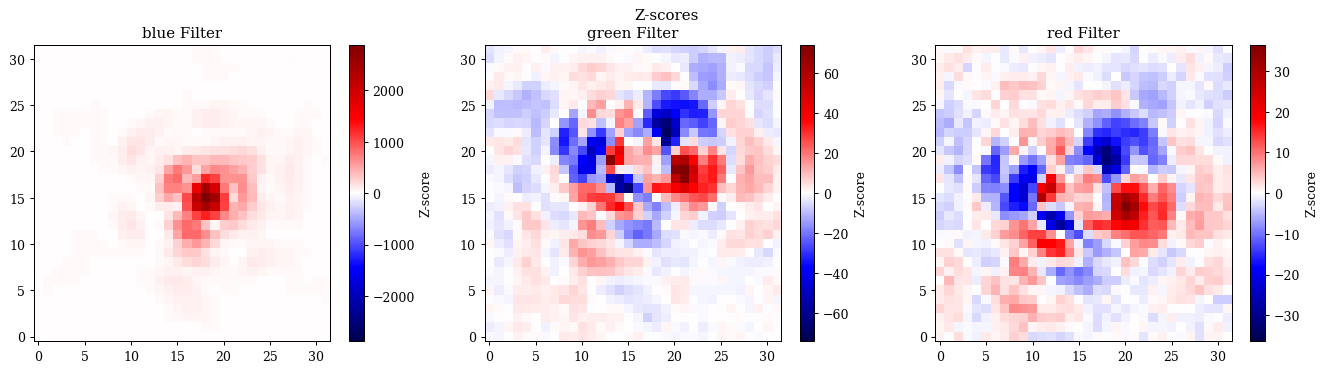

In [26]:
plt.figure(figsize=(15, 4))
plt.suptitle("Z-scores")

for i, obs in enumerate(observations):
    res = (obs.data - obs(sol.value, optics)) / obs.error
    v = np.nanmax(np.abs(res))
    plt.subplot(1, 3, i + 1)
    plt.title(f"{obs.filter} Filter")
    plt.imshow(res, cmap="seismic", vmin=-v, vmax=v)
    plt.colorbar(label="Z-score")

plt.tight_layout()
plt.show()

Okay, as we can see, we hit the max number of steps and don't recover the correct solution! Lets see how we can use our fisher matrix from before to reparametrise our problem.

In [27]:
# Define a loss function that projects our parameters from the latent space first
def projected_loss_fn(u, args):
    optics, observations, project_fn = args
    params = project_fn(u)
    return loss_fn(params, (optics, observations))

# Estimate our initial parameters from the data
params = {
    "wfe": np.zeros(7),
    "position": {obs.filter: obs.est_pos(optics) for obs in observations},
    "flux": {obs.filter: np.log10(obs.data.sum()) for obs in observations},
}
X0, unravel = ravel_pytree(params)

# Generate the projection matrix P, projection function, and initial vector
P = opt.eigen_projection(fmat=F)
project_fn = lambda u: unravel(X0 + np.dot(P, u))
X = np.zeros(P.shape[-1])

# # Get initial reduced chi-squared
chi2 = get_reduced_chi2(project_fn(X), optics, observations)
print("Initial reduced chi-squared:", chi2)

# Minimise algorithm
args = (optics, observations, project_fn)
solver = optx.BestSoFarMinimiser(optx.LBFGS(rtol=1e-6, atol=1e-6))
sol = optx.minimise(projected_loss_fn, solver, X, args, max_steps=256, throw=False)

# Get final reduced chi-squared
mle_params = project_fn(sol.value)
print("Final reduced chi-squared:", get_reduced_chi2(mle_params, optics, observations))
print("Steps:", int(sol.stats["num_steps"]))

Initial reduced chi-squared: 1553037.1824619938
Final reduced chi-squared: 0.9742223079396721
Steps: 29


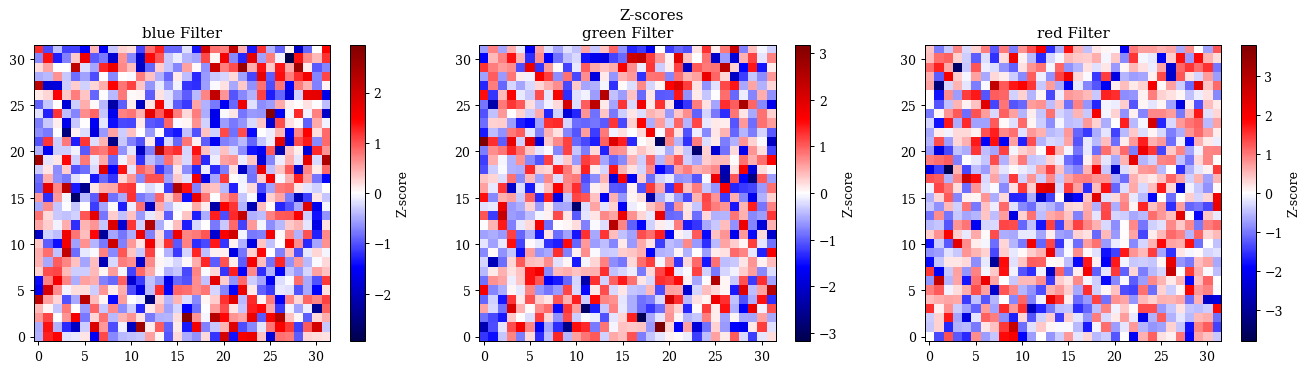

In [28]:
plt.figure(figsize=(15, 4))
plt.suptitle("Z-scores")

for i, obs in enumerate(observations):
    res = (obs.data - obs(mle_params, optics)) / obs.error
    v = np.nanmax(np.abs(res))
    plt.subplot(1, 3, i + 1)
    plt.title(f"{obs.filter} Filter")
    plt.imshow(res, cmap="seismic", vmin=-v, vmax=v)
    plt.colorbar(label="Z-score")

plt.tight_layout()
plt.show()

Excellent, not only can we see that now we recover the _correct_ solution, but we were able to converge in far fewer steps! Now that we know how to do this re-parameterisation we can have a look at how to sample our posterior distribution in this latent space using numpyro. 

---

## 7. Posterior Sampling with Numpyro

Now if we want to truly understand what our posteriors look like, we need to sample them directly. We can do this with [Numpyro](https://num.pyro.ai/en/stable/) which is a probabilistic programming library built on top of JAX. Numpyro is a _very_ powerful library, however in this also means that it can be quite complex to use for a lot of the simple problems we want to tackle. One of the main issues we face is that the samplers are much more stable when sampling from a _unit normal_ distribution. We could manually define unit priors and then transform them to the correct scales within our model, but this can be quite tedious and error prone. Luckily, we can use the same reparametrisation technique we used for optimisation to transform our problem into a unit normal space, which makes it much easier to sample from with numpyro! Lets look at how to do this with our hierarchical optical model.

It should be noted here that MCCM algorithms are _not_ optimisers, which means we need to first fit our data (which we have) in order to correctly sample our posteriors!

In [29]:
# Simple loglike function to compute the Hessian of the likelihood
def loglike_fn(params, args):
    optics, observations = args
    pred = np.array([obs(params, optics) for obs in observations])
    error = np.array([obs.error for obs in observations])
    data = np.array([obs.data for obs in observations])
    return stats.loglike(pred, data, error).sum()

# Calculate the Fisher information matrix at our best-fit parameters
args = (optics, observations)
f = lambda params: -loglike_fn(params, args)
H_mle, unflatten = batching.hessian(f, mle_params)

# Generate the projection matrix P, projection function, and initial vector
P = opt.eigen_projection(fmat=H_mle)
X0, unravel = ravel_pytree(mle_params)
mle_project_fn = lambda u: unravel(X0 + np.dot(P, u))

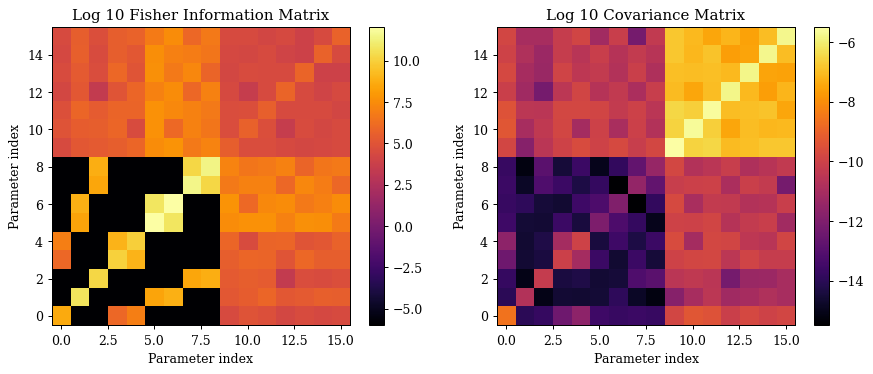

In [30]:
plt.figure(figsize=(10, 4))
ax = plt.subplot(1, 2, 1)
plt.imshow(np.log10(np.abs(H_mle + 1e-6)))
plt.colorbar()
ax.set(
    title="Log 10 Fisher Information Matrix",
    xlabel="Parameter index",
    ylabel="Parameter index",
)

ax = plt.subplot(1, 2, 2)
plt.imshow(np.log10(np.abs(np.linalg.inv(H_mle))))
plt.colorbar()
ax.set(
    title="Log 10 Covariance Matrix",
    xlabel="Parameter index",
    ylabel="Parameter index",
)

plt.tight_layout()
plt.show()

In [31]:
import numpyro as npy
import numpyro.distributions as dist

# Define our sampling function
def sampling_fn(args):
    X0, project_fn, optics, observations = args

    # Define the priors on the latent parameters
    latent_priors = npy.sample("Latent", dist.Uniform(-5, 5).expand(X0.shape))

    # Project the latent parameters
    params = project_fn(latent_priors)

    # Get the model predictions and data for each observation
    pred = np.array([obs(params, optics) for obs in observations])
    error = np.array([obs.error for obs in observations])
    data = np.array([obs.data for obs in observations])

    # Sample the Likelihood distribution
    return npy.sample("Sampler", dist.Normal(data, error), obs=pred)

# Define the MCMC sampler using NUTS
sampler = npy.infer.MCMC(
    npy.infer.NUTS(sampling_fn),
    num_warmup=1000,
    num_samples=2500,
    num_chains=jax.device_count(),
    progress_bar=True,
)

# Build the input arguments for the sampling function and run it
args = (X0, mle_project_fn, optics, observations)
sampler.run(jr.key(0), args)
sampler.print_summary()

sample: 100%|██████████| 3500/3500 [05:49<00:00, 10.02it/s, 7 steps of size 5.42e-01. acc. prob=0.90] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
 Latent[0]     -0.02      1.03     -0.03     -1.74      1.59   4193.92      1.00
 Latent[1]     -0.01      1.06     -0.01     -1.78      1.68   4498.04      1.00
 Latent[2]     -0.00      0.98     -0.01     -1.63      1.55   4704.01      1.00
 Latent[3]     -0.00      0.95      0.01     -1.56      1.49   3757.81      1.00
 Latent[4]      0.02      0.99      0.02     -1.56      1.68   6129.37      1.00
 Latent[5]      0.02      1.01      0.01     -1.74      1.56   4113.58      1.00
 Latent[6]     -0.01      0.99      0.00     -1.75      1.50   4940.96      1.00
 Latent[7]      0.02      1.04      0.01     -1.72      1.66   5110.49      1.00
 Latent[8]      0.02      1.03      0.02     -1.47      1.89   4052.82      1.00
 Latent[9]      0.01      1.03     -0.01     -1.53      1.76   4775.03      1.00
Latent[10]     -0.01      0.98      0.00     -1.53      1.65   5026.96      1.00
Latent[11]     -0.02      1

Great, we can see that our r_hat parameters are all close to unity, indicating good convergence. Lets have a look at the posterior samples, our estimate from the hessian we used to calculate the projection matrix, and what our true values are to see how well we did! Don't worry too much about the code below, its mostly just unpacking things to be plotted which can be quite tedious.

Parameter wfe_0 in chain MCMC posterior is not constrained


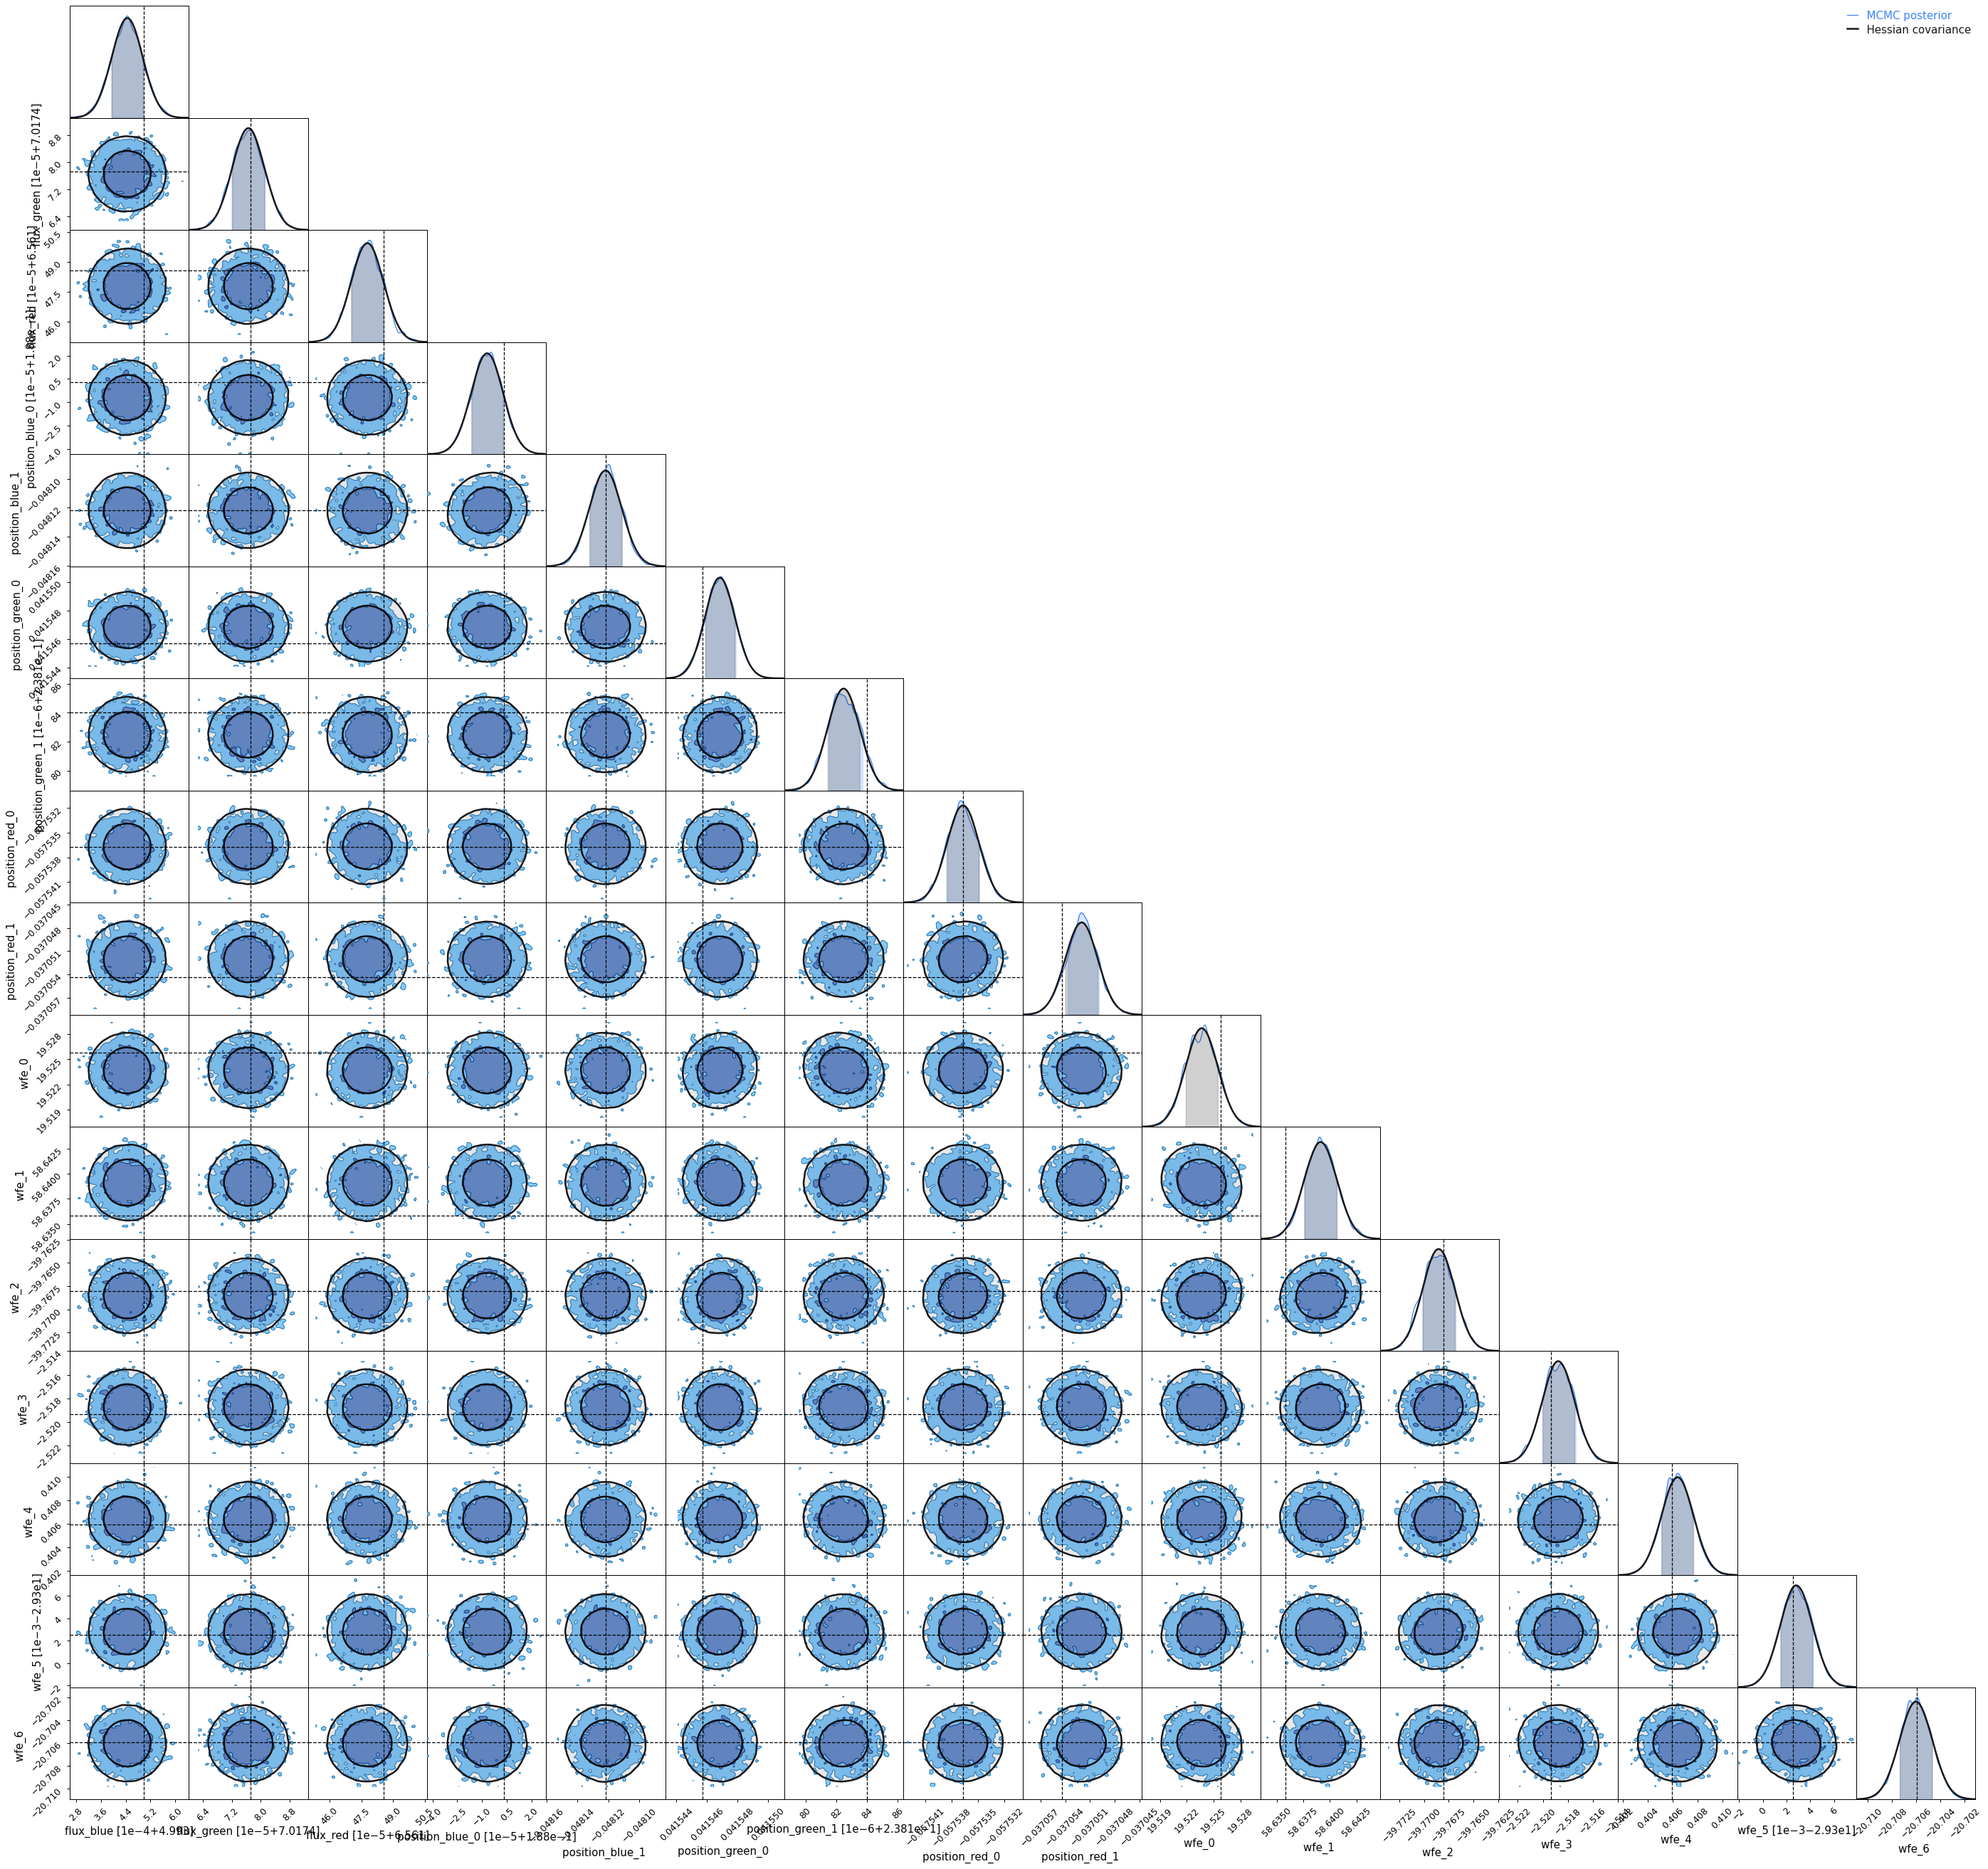

In [32]:
import itertools
import pandas as pd
from chainconsumer import ChainConsumer, Chain, Truth

# Helper function to get the scalar parameter names from the tree structure of the parameters
def scalar_names_from_tree(tree):
    names = []
    for path, leaf in jtu.leaves_with_path(tree):
        base = "_".join([str(p.key if hasattr(p, "key") else p) for p in path])
        leaf = np.asarray(leaf)
        if leaf.ndim == 0:
            names.append(base)
        else:
            for idx in itertools.product(*[range(s) for s in leaf.shape]):
                names.append(f"{base}_{'_'.join(map(str, idx))}")
    return names


# Unpack the latent samples into a dataframe
samples = sampler.get_samples()

# Project latent samples -> original parameter space
samples_dict = eqx.filter_vmap(mle_project_fn)(samples["Latent"])
flat_samples = jax.vmap(lambda p: ravel_pytree(p)[0])(samples_dict)

# Unpack the MLE parameters into a flat array for plotting
flat_mle, _ = ravel_pytree(mle_params)
flat_true, _ = ravel_pytree(true_params)

# Get the parameter names for the dataframe columns and the truth dict
param_names = scalar_names_from_tree(mle_params)
mcmc_df = pd.DataFrame(np.asarray(flat_samples), columns=param_names)
truth_dict = {k: float(v) for k, v in zip(param_names, np.asarray(flat_true))}

# Build chains
mcmc_chain = Chain(samples=mcmc_df, name="MCMC posterior")
cov_chain = Chain.from_covariance(
    mean=np.asarray(flat_mle),
    covariance=np.asarray(np.linalg.inv(H_mle)),
    columns=param_names,
    name="Hessian covariance",
    color="k",
    shade=True,
    linewidth=2.0,
    shade_alpha=0.1,
)

# Plot
c = ChainConsumer()
c.add_chain(mcmc_chain)
c.add_chain(cov_chain)
c.add_truth(Truth(location=truth_dict))
fig = c.plotter.plot()

---

## Nested Sampling (coming soon)

Bayesian evidence estimation and model comparison with nested sampling and the fisher matrix and variational inference?